# Teach a chatbot to read your documents

**Embed** text into numbers. **Search** for the closest numbers. **Answer** using what was found.

### How to use this notebook

1. Every cell already works. You do **not** need to write new code.
2. Some cells ask you to **guess first**. Type your guess, run the cell, then see if you were right.
3. **CORE** cells are for everybody. **BONUS** cells are for when you finish early.
4. Runtime: CPU is enough. Do **not** ask for a GPU.

**Driver** types. **Navigator** reads the guess out loud and says what they expect to happen. Swap roles at the break.

## CELL 1 - Setup  (CORE)

Just run it. Nothing is installed.

In [ ]:
# Nothing is installed. Colab already has everything we need.
import sentence_transformers

TIMINGS = {}


def _probe_answer_engine():
    """Work out which model will write our answers, and say why.

    Reported at the start rather than at the end, so the room knows which path it
    is on from minute one instead of discovering it two hours in.
    """
    try:
        from google.colab import ai
    except Exception as exc:
        return "offline model (slower)", f"cannot import google.colab.ai ({type(exc).__name__})"
    if not hasattr(ai, "generate_text"):
        names = ", ".join(n for n in dir(ai) if not n.startswith("_"))
        return "offline model (slower)", f"google.colab.ai has no generate_text; it offers: {names}"
    return "Colab AI (fast)", ""


print("SETUP OK - sentence-transformers", sentence_transformers.__version__)

_engine_name, _engine_reason = _probe_answer_engine()
print("Answer engine:", _engine_name)
if _engine_reason:
    print("  reason:", _engine_reason)
    print("  This still works. Answers just take a little longer.")

print("\nShow a GREEN paper if you can see SETUP OK.")

## CELL 2 - Load the handbook  (CORE)

35 paragraphs from a fictional college. Run it, do not open it.

In [ ]:
# @title Run this cell to load the handbook (35 paragraphs) { display-mode: "form" }
# Riverstone Polytechnic is a fictional college. Nothing here is real.
PARAGRAPHS = [
    "Riverstone Polytechnic is a small technical college with about 2,400 students. It teaches Informatics, Electrical Engineering, and Business Administration. The campus has three buildings: the Main Building, the Workshop, and the Library. All classes are taught in English. The college was founded in 1978 and its colours are dark green and grey.",
    "The academic year has two semesters. The first semester runs from early September to late January. The second semester runs from early February to late June. July and August are the long holiday. Each semester has 16 teaching weeks and 2 examination weeks at the end.",
    "Students must register for their subjects before the semester starts. Registration opens four weeks before the first day of class and closes on the Friday before class begins. Registration is done online through the student portal. A student who does not register cannot enter the examination room, even if they attended every class.",
    "A student who registers after the deadline pays a late registration fee of 120 RSD. Late registration is only possible during the first two weeks of the semester. After the second week the portal closes completely and the student must wait for the next semester. The fee cannot be paid in cash and must be paid through the portal.",
    "To graduate from a three-year Informatics programme, a student needs 144 credits in total. This includes 108 credits from required subjects, 24 credits from elective subjects, and 12 credits from the internship and the final project together. A student who has 143 credits does not graduate.",
    "A student may take a maximum of 24 credits in one semester. Students who have a grade point average below 2.50 are limited to 18 credits, so that they have more time for each subject. A student who wants to take more than 24 credits needs written permission from the head of programme.",
    "Grades use letters. An A is 4.0 points, a B is 3.0 points, a C is 2.0 points, a D is 1.0 point, and an E is 0 points. There are no plus or minus grades at Riverstone. The letter is decided by the total mark: 80 and above is an A, 70 to 79 is a B, 60 to 69 is a C, 50 to 59 is a D, and below 50 is an E.",
    "The pass mark for every subject is 50. A student who scores 49 has failed the subject. For laboratory subjects the student must also pass the practical part separately, which means at least 50 in the practical mark as well as 50 in the total mark. A good written exam cannot rescue a failed practical.",
    "A failed subject must be repeated. A student may repeat the same subject a maximum of three times. After the third failure the student is removed from the programme and may apply again as a new student after one full year. Repeating a subject costs 200 RSD each time.",
    "The grade point average is the sum of grade points multiplied by credits, divided by the total credits. Only the best attempt at a repeated subject is counted. The average is printed on the transcript with two decimal places. A student needs an average of at least 2.00 to graduate.",
    "A student must attend at least 74 percent of the classes in every subject to be allowed into the examination. Attendance is counted by the lecturer at the start of each class. A student who arrives more than 20 minutes late is marked absent for that class, but is still allowed to stay and study.",
    "A student who is sick must send a medical certificate to the student affairs office within five working days. An accepted certificate means the absence is not counted against the attendance requirement. A certificate sent later than five working days is refused, even if the illness was real and serious.",
    "The library is open from 08:00 to 20:00 from Monday to Friday. On Saturday it is open from 09:00 to 14:00. It is closed on Sunday and on public holidays. During the two examination weeks the library stays open until 23:00 every day including Sunday, and free tea is served at 21:00.",
    "A student may borrow four books at the same time for two weeks each. A book may be renewed twice, so the longest possible loan is six weeks. Reference books, final project reports, and journals may be read inside the library but never taken out of the building.",
    "A late book costs 2 RSD per day, and the fine never grows past 60 RSD no matter how late the book is. All library fines are cancelled on the thirteenth day of each month, which students call Forgiveness Day. A student with an uncancelled fine above 30 RSD cannot borrow anything new.",
    "The computer laboratory in the Workshop building is open from 07:30 to 21:00 from Monday to Friday, and from 08:00 to 16:00 on Saturday. Outside these hours the door is locked and the card reader is switched off. Students working on a final project may ask for evening access using a special card.",
    "Food and drink are not allowed in the computer laboratory. Water in a closed bottle is allowed if it is kept on the floor and not on the desk. A student who spills a drink on a keyboard pays 45 RSD for a replacement. Shoes must be worn at all times in the laboratory.",
    "Every student gets a campus WiFi account with their student number as the username. The first password is the date of birth of the student in the form DDMMYYYY and must be changed within seven days. A student may connect a maximum of three devices at the same time. Sharing the account with another person is forbidden.",
    "The campus network blocks video streaming between 09:00 and 15:00 on teaching days, so that the connection stays fast for class work. Downloading very large files during these hours may cause the account to be paused for one hour. The block is lifted completely during the holiday months.",
    "Each student receives a printing quota of 180 pages per semester. Pages above the quota cost 0.15 RSD each. Unused pages do not move to the next semester, and they cannot be given to another student. Colour printing counts as three pages against the quota.",
    "Every Informatics student must complete an internship of at least 480 hours, which is about twelve weeks of full-time work. The internship normally happens between the fourth and fifth semester. The company must be approved by the head of programme before the student starts, and an internship that was not approved in advance does not count.",
    "The internship report is due 30 days after the last day of work at the company. The report must be between 25 and 40 pages and must be signed by the company supervisor. A report sent late loses 5 marks for every week of delay, and a report more than four weeks late is graded E.",
    "Each student on internship has two supervisors: one lecturer from the college and one engineer from the company. The lecturer visits the company once during the internship. The final internship mark is 60 percent from the lecturer and 40 percent from the company supervisor.",
    "The final project is done alone, not in a group. It must solve a real technical problem and must include working software or hardware. The student chooses a topic in the fifth semester and must have it approved by a lecturer who agrees to supervise the work. The project is worth 6 credits.",
    "The final project report is submitted in the sixth semester, four weeks before the examination weeks. After submission the student defends the project in front of three lecturers for 45 minutes: 15 minutes of presentation and 30 minutes of questions. The defence is open and other students may watch.",
    "Every final project report must contain a one-page section called Reflection in Numbers, placed immediately after the conclusion. This section must list exactly seven measurements taken from the own work of the student, each with its unit. A report with six or eight measurements is returned to the student without being graded.",
    "Riverstone offers three kinds of scholarship: the Merit Scholarship for high grades, the Access Scholarship for students with low family income, and the Workshop Scholarship for students who help maintain the laboratories for four hours a week. A student may hold only one scholarship at a time.",
    "The Merit Scholarship requires a grade point average of at least 3.40 and no failed subject in the previous two semesters. It pays 1,800 RSD per semester. The average is checked again every semester, and a student whose average drops below 3.20 loses the scholarship at the end of that semester.",
    "Scholarship applications open on the first Monday of the semester and close 21 days later. Applications are made on paper at the student affairs office, not online, because they need original documents. Results are announced six weeks after the deadline. A late application is not read at all.",
    "The student identity card is needed to enter the library, the laboratories, and the examination rooms. It also works as a payment card in the cafeteria. The card must be carried on campus at all times and shown to any member of staff who asks for it.",
    "A lost identity card is replaced for 25 RSD and the new card is ready after four working days. A student may replace the card twice without explanation. A third replacement needs a short written letter addressed to the Dean, explaining what happened to the previous two cards.",
    "A grey cat lives in the Main Building and is called Bytes. Bytes has an honorary student number, S000000, and a photograph on the wall of the student affairs office. Feeding Bytes inside the computer laboratory is not allowed. Bytes has attended more lectures than any student in the history of the college.",
    "The cafeteria is open from 07:00 to 18:00 on teaching days and serves a hot meal between 11:30 and 14:00. Durian is not allowed inside the building, and this is the only food rule the college has ever written down. Payment is by student card or by phone, never in cash.",
    "Riverstone has eleven student clubs, including robotics, football, photography, and a club that only repairs old computers. A club needs at least twelve members to receive money from the college. Clubs may book a room in the Main Building on any evening except Friday.",
    "The student affairs office is on the ground floor of the Main Building, room G-12. It is open from 08:30 to 16:00 on teaching days and closes for lunch between 12:00 and 13:00. Questions about registration, scholarships, certificates, and lost cards all go to this office.",
]

print(len(PARAGRAPHS), "paragraphs loaded.")
print("Paragraph 5 starts:", PARAGRAPHS[4][:55], "...")

## CELL 3 - Load the model  (CORE)

Run it and wait for MODEL OK.

In [ ]:
# The model that turns text into numbers. About 91 MB, downloaded once.
import time

from sentence_transformers import SentenceTransformer

_started = time.perf_counter()
model = SentenceTransformer("all-MiniLM-L6-v2")
TIMINGS["load model"] = time.perf_counter() - _started

print(f"MODEL OK - ready in {TIMINGS['load model']:.1f} seconds")

## CELL 4 - Text becomes numbers  (CORE)

Each sentence becomes a long list of numbers, called an **embedding**.

**Guess first:** how many numbers does one sentence become?

In [ ]:
guess = 100        # <-- change this number to your guess

SENTENCES = [
    "I love cats.",
    "I like kittens.",
    "My dog is very friendly.",
    "The stock market fell sharply today.",
    "Interest rates went up again.",
]

vectors = model.encode(SENTENCES, normalize_embeddings=True)
print("you guessed:", guess)
print("real answer:", vectors.shape[1], "numbers per sentence")

## CELL 5 - Similar meaning means a high score  (CORE)

We compare **I love cats.** against all five sentences.

**Guess first:** which one of the SENTENCES gets the highest score?

In [ ]:
guess = "My dog is very friendly."

query = "I love cats."
query_vector = model.encode([query], normalize_embeddings=True)[0]
scores = vectors @ query_vector

print("you guessed:", guess)
print(f"\nCompared with: {query}\n")
for sentence, score in sorted(zip(SENTENCES, scores), key=lambda pair: -pair[1]):
    print(f"  {score:+.2f}   {sentence}")

## CELL 6 - Your own sentence  (BONUS)

Change the sentence, run, and see where it lands.

In [ ]:
my_sentence = "Small cats are the best animals."   # <-- change this

my_vector = model.encode([my_sentence], normalize_embeddings=True)[0]
for sentence, score in sorted(zip(SENTENCES, vectors @ my_vector), key=lambda pair: -pair[1]):
    print(f"  {score:+.2f}   {sentence}")

## CELL 7 - Turn the whole handbook into numbers  (CORE)

35 paragraphs. Takes a few seconds. Wait for the shape to print.

In [ ]:
import time

_started = time.perf_counter()
PARAGRAPH_VECTORS = model.encode(PARAGRAPHS, normalize_embeddings=True)
TIMINGS["embed handbook"] = time.perf_counter() - _started

print("shape:", PARAGRAPH_VECTORS.shape, f"in {TIMINGS['embed handbook']:.1f} seconds")
print("35 paragraphs, 384 numbers each. Show a GREEN paper if you see (35, 384).")

## CELL 8 - The search function  (CORE)

Read it and run it. Three lines do the work: turn the question into numbers, give every paragraph a score, keep the best ones.

In [ ]:
# Read it, run it, do not change it.
def search(question, k=3):
    """Return the k handbook paragraphs closest in meaning to the question."""
    question_vector = model.encode([question], normalize_embeddings=True)[0]
    scores = PARAGRAPH_VECTORS @ question_vector      # one score for every paragraph
    best = scores.argsort()[::-1][:k]                 # highest score first
    return [(int(i) + 1, float(scores[i]), PARAGRAPHS[i]) for i in best]


def show(hits):
    """Print search results in a readable way."""
    for number, score, text in hits:
        print(f"score {score:+.2f}   paragraph {number}:  {text[:85]}...")


print("search() and show() are ready.")

## CELL 9 - Ask your own question  (CORE)

Change the question, run it, then tell your partner **which paragraph number** came back.

The model only understands English today, so ask in English. Ideas:

- How many books can I borrow?
- When is the library open on Saturday?
- Can I eat in the computer lab?
- How long is the internship?
- What happens if I fail a subject three times?
- Who is Bytes?

In [ ]:
my_question = "How many books can I borrow?"   # <-- change this

show(search(my_question, k=3))

## CELL 10 - Search always answers, even when it should not  (CORE)

The handbook says nothing about France.

**Guess first:** will the scores be high or low? Write `"high"` or `"low"`.

In [ ]:
guess = "high"     # <-- "high" or "low"

print("you guessed:", guess, "\n")
show(search("What is the capital of France?", k=3))
print("\nLesson: search ALWAYS returns something. Read the score.")

## CELL 11 - How many paragraphs?  (BONUS)

Change `k` to 1, then to 8. What changes, and what does not?

In [ ]:
show(search(my_question, k=1))   # <-- try 1, then try 8

## CELL 12 - Put the paragraphs into a prompt  (CORE)

Run it and **read the text it prints**. That text is everything the model will see. This is the whole idea.

In [ ]:
def build_prompt(question, hits):
    """Glue the found paragraphs and the question into one piece of text."""
    context = "\n\n".join(f"[Paragraph {n}] {t}" for n, s, t in hits)
    return (
        "Use ONLY the handbook text below to answer the question.\n"
        "If the answer is not in the text, say: I cannot find this in the handbook.\n"
        "Always say which paragraph number you used.\n\n"
        f"Handbook:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )


example = "How many books can I borrow?"
print(build_prompt(example, search(example, k=1)))

## CELL 13 - The answer function  (CORE)

Run it. Do not change it.

In [ ]:
# Read it, run it, do not change it.
# First choice is the Gemini model built into Colab: no key, no download, instant.
# If your account cannot use it, this falls back to a small offline model and says so.
import time

_local = {}
_engine = {"reported": None}


def _local_answer(prompt):
    if not _local:
        print("   loading a small offline model, about 300 MB, one time only...")
        from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

        name = "google/flan-t5-small"
        _local["tokenizer"] = AutoTokenizer.from_pretrained(name)
        _local["model"] = AutoModelForSeq2SeqLM.from_pretrained(name)
    tokenizer, small_model = _local["tokenizer"], _local["model"]
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    output = small_model.generate(**inputs, max_new_tokens=48)
    return tokenizer.decode(output[0], skip_special_tokens=True)


def _report(engine, reason=""):
    """Announce the engine once, with the exact reason for any fallback.

    Naming the reason matters: a renamed API and an ineligible account both raise,
    and without this they would look identical.
    """
    if _engine["reported"] != engine:
        _engine["reported"] = engine
        print(f"[engine: {engine}]" + (f" {reason}" if reason else ""))


def answer(prompt):
    """Send a prompt to a language model and return its text."""
    started = time.perf_counter()
    try:
        from google.colab import ai

        text = ai.generate_text(prompt)
        _report("Colab AI")
    except Exception as exc:
        _report("offline model", f"{type(exc).__name__}: {str(exc)[:140]}")
        text = _local_answer(prompt)
    TIMINGS["last answer"] = time.perf_counter() - started
    return text


def ask(question, k=3):
    """The whole system: search, build the prompt, then answer."""
    hits = search(question, k=k)
    return answer(build_prompt(question, hits)), hits


print("answer() and ask() are ready.")

## CELL 14 - Ask WITHOUT the handbook  (CORE)

Five rules in this handbook were invented for today. No chatbot in the world has ever seen them.

**Guess first:** What the model says when there is no handbook at all? will it say "I do not know", or will it invent a number? Write `"know"` or `"invent"`.

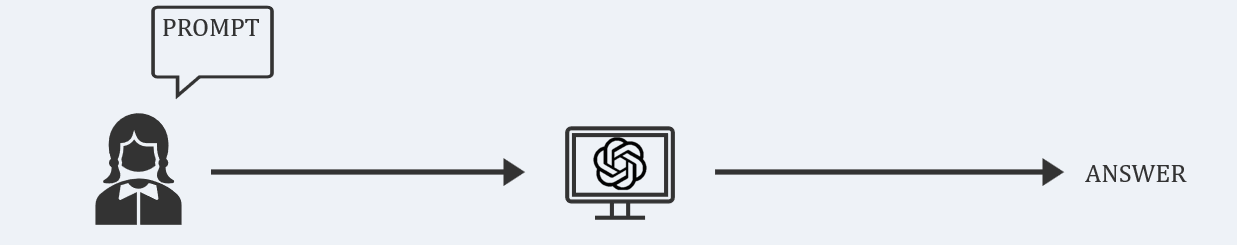

In [ ]:
question = "What is the minimum attendance to sit the exam?" 

guess = "know"     # <-- "know" or "invent"

print("you guessed:", guess, "\n")

# No handbook. We insist on a number, the way many real applications do.
prompt_without_handbook = (
    f"Question about Riverstone Polytechnic: {question}\n"
    "Reply with one percentage and nothing else. "
    "Do not ask me for more information."
)

print(prompt_without_handbook)
print()
print(answer(prompt_without_handbook))

## CELL 15 - Ask WITH the handbook  (CORE)

Now... Same question, but the model gets the handbook.

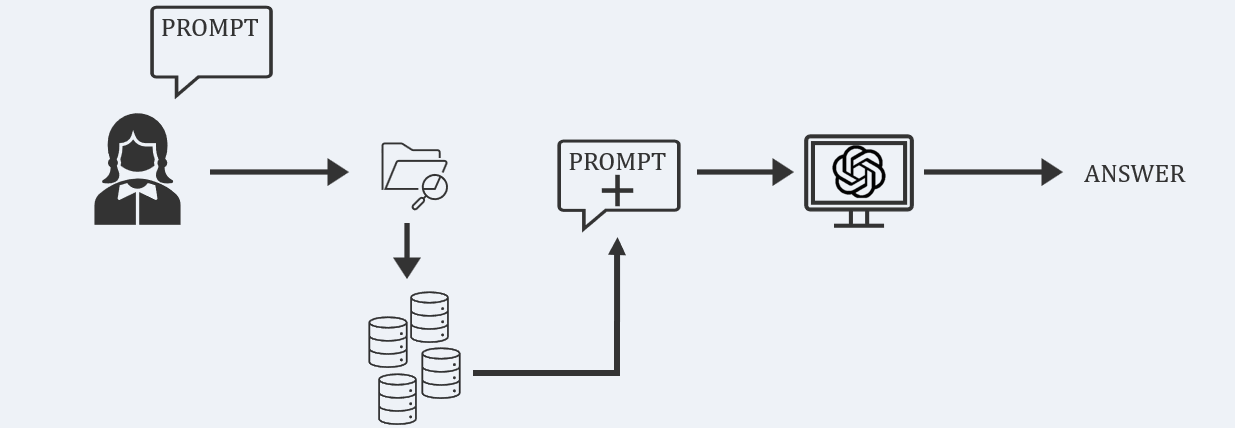

In [ ]:
question = "What is the minimum attendance to sit the exam?"   # <-- try your own

reply, hits = ask(question)
print(reply)
print("\n--- the paragraphs it was given ---")
show(hits)

## CELL 16 - Measure it  (BONUS)

15 questions where we already know the right paragraph. This is how real teams check whether a search system is any good.

In [ ]:
# 15 questions where we already know the right paragraph.
CHECK_QUESTIONS = [
    ("How many credits do I need to graduate?", 5),
    ("What is the pass mark for a subject?", 8),
    ("When is the library open on Saturday?", 13),
    ("How many books can I borrow at once?", 14),
    ("How long is the internship?", 21),
    ("When is the internship report due?", 22),
    ("What happens if I fail the same subject three times?", 9),
    ("Can I eat in the computer lab?", 17),
    ("How much is the late registration fee?", 4),
    ("What GPA do I need for the Merit Scholarship?", 28),
    ("What is the minimum attendance to sit the exam?", 11),
    ("What is Forgiveness Day?", 15),
    ("How many pages can I print each semester?", 20),
    ("What is the Reflection in Numbers section?", 26),
    ("What do I need for a third replacement ID card?", 31),
]

found_count = 0
for question_text, expected in CHECK_QUESTIONS:
    found = [number for number, score, text in search(question_text, k=3)]
    ok = expected in found
    found_count += ok
    print("OK  " if ok else "MISS", f"want p{expected}", "got", found, "|", question_text)

print(f"\nTop-3 hit rate: {found_count} out of {len(CHECK_QUESTIONS)}")

## CELL 17 - Lost your connection?

Use the menu: **Runtime -> Run all**. Then run this cell to check that everything came back.

In [ ]:
# Lost your connection? Use the menu: Runtime -> Run all. It takes about a minute.
# This cell only CHECKS whether everything is still here.
missing = [
    name
    for name in ["PARAGRAPHS", "model", "PARAGRAPH_VECTORS", "search", "answer", "TIMINGS"]
    if name not in globals()
]

if missing:
    print("MISSING:", ", ".join(missing))
    print("\nFix it with the menu: Runtime -> Run all")
else:
    print("ALL GOOD -", len(PARAGRAPHS), "paragraphs ready. Keep going.")

## What real systems add

Today you built the smallest version that works. A real system adds:

1. **Chunking** - real documents are long, so they are cut into small pieces first.
2. **Keyword search as well as meaning search** - the two together beat either alone.
3. **Reranking** - a second, slower model re-orders the best 20 results.
4. **Measuring** - exactly what the check-questions cell did, but with hundreds of questions.
5. **Fresh information** - a model trained last year does not know about last week. Search does.

**Homework:** replace the 35 paragraphs in CELL 2 with your own text - your class notes, a
game wiki, a football rulebook - and every other cell keeps working.